# Part A: Regression (Medical Cost Prediction)

Objective: Build a Linear Regression model to predict medical insurance charges

In [1]:
# import important libraries 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score ,root_mean_squared_error
from sklearn.metrics import confusion_matrix,classification_report,precision_score,recall_score,accuracy_score

SECTION 1 – Data Understanding (Mandatory) 

In [2]:
# 1. Load the dataset and display:
df = pd.read_csv('C:/Users/swapn/SUPERVISED_LEARNING/Dataset/insurance.csv')

print(df.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [3]:
# Shape 
print(df.shape)

(1338, 7)


In [4]:
# Column names 
print(df.columns)

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')


In [5]:
# Data types 
print(df.dtypes)

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


In [6]:
# First 5 rows 
print(df.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [7]:
# 2. Check:  
# Missing values
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [8]:
# Duplicate rows 
print(df.duplicated())
print(df.drop_duplicates())

0       False
1       False
2       False
3       False
4       False
        ...  
1333    False
1334    False
1335    False
1336    False
1337    False
Length: 1338, dtype: bool
      age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1337 rows x 7 

In [9]:
# 3. Perform EDA: 

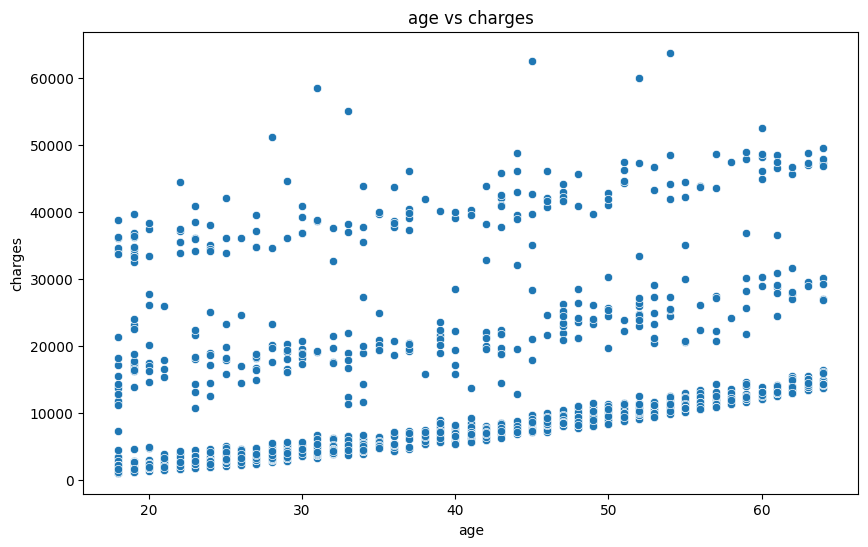

In [10]:
# Scatter plot: age vs charges 
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='age', y='charges')
plt.title('age vs charges')
plt.xlabel('age')
plt.ylabel('charges')
plt.show()

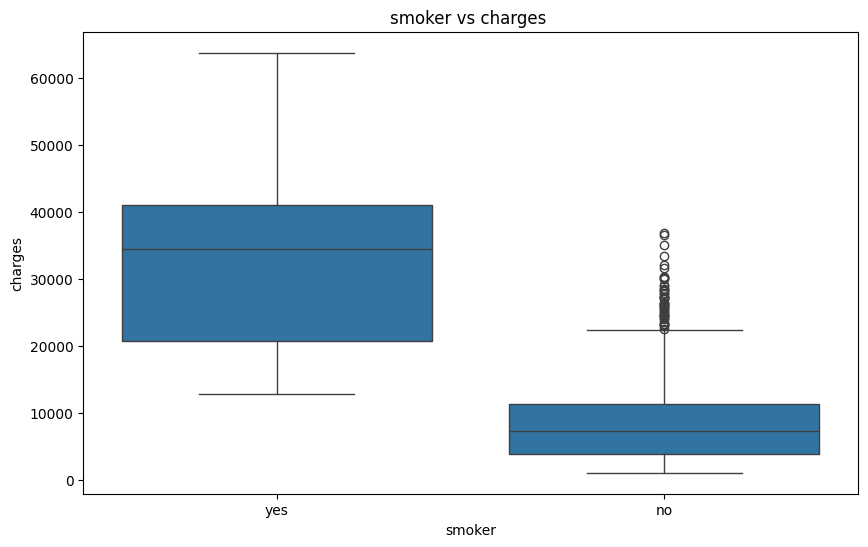

In [11]:
# Boxplot: smoker vs charges 
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='smoker', y='charges')
plt.title('smoker vs charges ')
plt.xlabel('smoker')
plt.ylabel('charges')
plt.show()

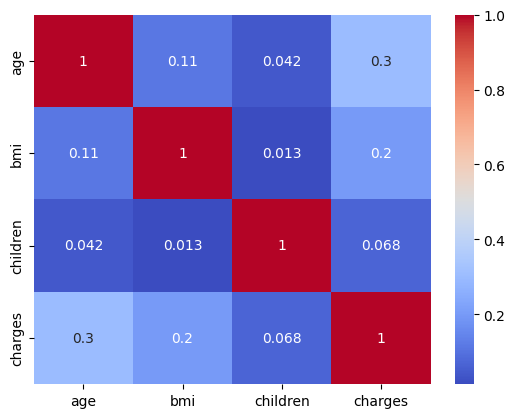

In [12]:
# Correlation heatmap 
corr = df.corr(numeric_only= True)
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()

4. Write 3 observations from EDA. 
  1) Age is then charges will slightly increases .
  2) boxplot show the outloiers at the no smokers . 
  3) highest relation betwwen agw and charges
  4) lowest relation betwwen children and bmi

SECTION 2 – Data Preprocessing

In [13]:
# 5. Encode categorical variables properly. 
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])


In [14]:
df= pd.get_dummies(df,columns=['region']).astype(int)

In [15]:
print(df.dtypes)

age                 int64
sex                 int64
bmi                 int64
children            int64
smoker              int64
charges             int64
region_northeast    int64
region_northwest    int64
region_southeast    int64
region_southwest    int64
dtype: object


In [16]:
print(df)

      age  sex  bmi  children  smoker  charges  region_northeast  \
0      19    0   27         0       1    16884                 0   
1      18    1   33         1       0     1725                 0   
2      28    1   33         3       0     4449                 0   
3      33    1   22         0       0    21984                 0   
4      32    1   28         0       0     3866                 0   
...   ...  ...  ...       ...     ...      ...               ...   
1333   50    1   30         3       0    10600                 0   
1334   18    0   31         0       0     2205                 1   
1335   18    0   36         0       0     1629                 0   
1336   21    0   25         0       0     2007                 0   
1337   61    0   29         0       1    29141                 0   

      region_northwest  region_southeast  region_southwest  
0                    0                 0                 1  
1                    0                 1                 0  


In [17]:
# 6. Separate features (X) and target (y). 

X = df.drop('charges',axis=1)   # features

y = df['charges']   # target

In [18]:
# 7. Perform train-test split (80-20). 

X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [19]:
# 8. Apply feature scaling (if required). 
# 9. Explain why scaling is / isn’t required. 

# feature scaling is used to when outlier are in the feature but here not any outlier in  dataset  
# target value not apply feature scalling beacuse data leakege

SECTION 3 – Model Building 

In [20]:
# 10. Train a Linear Regression model. 
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
# 11. Display: 

#  Intercept 
print(model.intercept_)

#  Coefficients
print(model.coef_)

-12190.574128571941
[ 2.57096202e+02 -1.72621748e+01  3.35633616e+02  4.27589784e+02
  2.36556741e+04  4.62867198e+02  9.86618374e+01 -2.04777180e+02
 -3.56751855e+02]


In [22]:
# 12. Write the regression equation. 
# y=a+bx

SECTION 4 – Model Evaluation 

In [23]:
# 13. Predict on test data. 
y_pred = model.predict(X_test)

In [24]:
# 14. Calculate: 

#  MAE 
print("MAE-:\n",mean_absolute_error(y_test,y_pred))

#  MSE 
print("MSE-:\n",mean_squared_error(y_test,y_pred))

#  RMSE 
print("RMSE-:\n",root_mean_squared_error(y_test,y_pred))

#  R2 Score
print("R2 Score-:\n",r2_score(y_test,y_pred))

MAE-:
 4176.2683952992475
MSE-:
 33566439.73530042
RMSE-:
 5793.655127404497
R2 Score-:
 0.7837888448800693


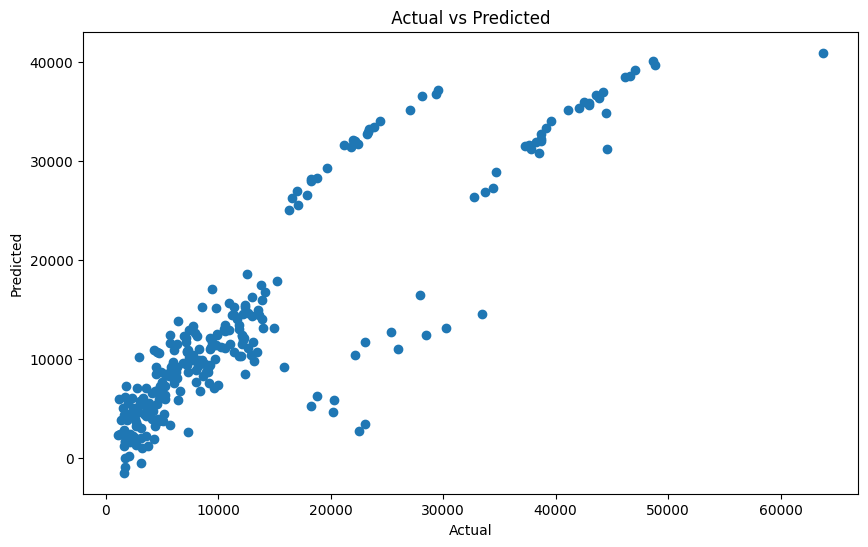

In [25]:
# 15. Plot:

#  Actual vs Predicted  
plt.figure(figsize=(10,6))
plt.scatter(y_test,y_pred)
plt.title(' Actual vs Predicted ')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

In [26]:
# 16. Interpret R2 score. 
# r2_score is 0.78 near to the 1 the model is good 

In [27]:
# SECTION 5 – Business Insights 

# 17. Which variable impacts charges the most? 
# BMI And Age

# 18. How much more do smokers pay? 
# yes

# 19. Is BMI statistically impactful? 
# yes

# 20. Can this model be used in production? Why or why not?
# yes